<a href="https://colab.research.google.com/github/Lorenasaquicoray/Applied-Machine-Learning/blob/main/Training%20CNN%20Classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 4: Training a CNN Classifier

This lab is based on the PyTorch tutorial ["Training a Classifier."](https://docs.pytorch.org/tutorials/beginner/blitz/cifar10_tutorial.html#training-a-classifier)

It is highly recommended to use Google Colab for this assignment, as dependency errors or certificate issues may pop up when running locally. Be sure to run all code blocks and answer the 3 questions.

First, we import all the modules needed:

In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
import multiprocessing

We want to normalize the input images to be zero-centered and define a transform to do this. The original ranges of the channel values are between 0 and 1.

## Question 1

What do the 0.5 values in the [Normalize](https://docs.pytorch.org/vision/stable/generated/torchvision.transforms.Normalize.html#torchvision.transforms.Normalize) function do?

The 0.5 values represent the mean and the standard deviation for the three color channels (Red, Green, and Blue). The first (0.5, 0.5, 0.5) is the mean, and the second (0.5, 0.5, 0.5) is the standard deviation. Applying the formula (input − mean) / std transforms the image pixel values from the range [0,1] to the range [-1, 1] and makes it zero-centered. Centering the data helps neural networks train efficiently and improves convergence.

In [ ]:
transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

Now we set the batch size to 4 (i.e., we process 4 inputs before updating weights) and load in the CIFAR10 dataset. This dataset contains 10 image classes (listed in the following code) and 6000 32x32 images per class. Here, the training sets (on which the algorithm learns weights) and test sets (on which algorithm performance is evaluated) are defined.

In [ ]:
batch_size = 4

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size,
                                          shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size,
                                         shuffle=False, num_workers=2)

classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

100%|██████████| 170M/170M [00:13<00:00, 12.7MB/s]


The following code shows a random batch of images and prints out their class labels.

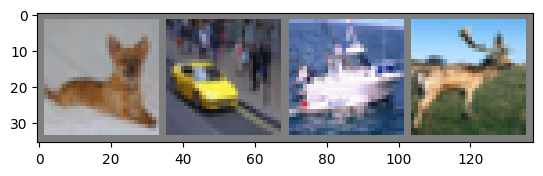

dog   car   ship  deer 


In [ ]:
def imshow(img):
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()


# get some random training images
dataiter = iter(trainloader)
images, labels = next(dataiter)

# show images
imshow(torchvision.utils.make_grid(images))
# print labels
print(' '.join(f'{classes[labels[j]]:5s}' for j in range(batch_size)))

This code defines our neural network.

## Question 2

What are the input and output sizes of each of the 6 network layers?
CIFAR-10 (32X32 IMAGES)

self.conv1 input size: 3 × 32 × 32

formula: input(3 X 32 X 32)

32 - 5+ + 1 = 28

output = 6 x 28 x28


self.conv1 output size: 6 × 28 × 28

self.pool input size (after conv1): 6 × 28 × 28

self.pool output size: 6 × 14 × 14

pool = 28/2 = 14

self.conv2 input size: 6 × 14 × 14

self.conv2 output size: 16 × 10 × 10

self.pool input size (after conv2): 16 × 10 × 10

self.pool output size: 16 × 5 × 5

self.fc1 input size: 400

self.fc1 output size: 120

self.fc2 input size: 120

self.fc2 output size: 84

self.fc3 input size: 84

self.fc3 output size: 10

In [ ]:
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 6, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = torch.flatten(x, 1) # flatten all dimensions except batch
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x


net = Net()

We define the loss function (cross entropy loss) and our gradient descent parameters.

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9)

Now we're ready to train our network!

In [ ]:
for epoch in range(2):  # loop over the dataset multiple times

    running_loss = 0.0
    for i, data in enumerate(trainloader, 0):
        # get the inputs; data is a list of [inputs, labels]
        inputs, labels = data

        # zero the parameter gradients
        optimizer.zero_grad()

        # forward + backward + optimize
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # print statistics
        running_loss += loss.item()
        if i % 2000 == 1999:    # print every 2000 mini-batches
            print(f'[{epoch + 1}, {i + 1:5d}] loss: {running_loss / 2000:.3f}')
            running_loss = 0.0

print('Finished Training')

[1,  2000] loss: 2.186
[1,  4000] loss: 1.833
[1,  6000] loss: 1.654
[1,  8000] loss: 1.541
[1, 10000] loss: 1.516
[1, 12000] loss: 1.454
[2,  2000] loss: 1.393
[2,  4000] loss: 1.356
[2,  6000] loss: 1.363
[2,  8000] loss: 1.319
[2, 10000] loss: 1.324
[2, 12000] loss: 1.300
Finished Training


To keep from having to retrain the network, we can save all of the learned weights as `cifar_net.pth`.

In [ ]:
PATH = './cifar_net.pth'
torch.save(net.state_dict(), PATH)

Now, in case you got interrupted after training, you don't have to run all of the above code blocks above; you can just load in the weights:

In [ ]:
net = Net()
net.load_state_dict(torch.load(PATH, weights_only=True))

<All keys matched successfully>

Let's test the network's performance now. We first load in an example batch from the test dataset and view the network's labels for them.

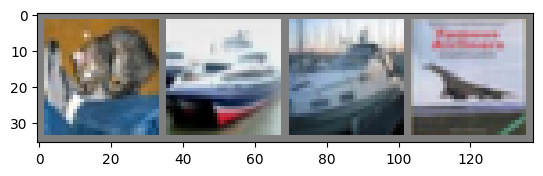

GroundTruth:  cat   ship  ship  plane
Predicted:  cat   car   plane car  


In [ ]:
dataiter = iter(testloader)
images, labels = next(dataiter)

# print images
imshow(torchvision.utils.make_grid(images))
print('GroundTruth: ', ' '.join(f'{classes[labels[j]]:5s}' for j in range(4)))

outputs = net(images)

_, predicted = torch.max(outputs, 1)

print('Predicted: ', ' '.join(f'{classes[predicted[j]]:5s}'
                              for j in range(4)))

Finally, we examine the network's performance on the entire test dataset.

In [ ]:
correct = 0
total = 0
# since we're not training, we don't need to calculate the gradients for our outputs
with torch.no_grad():
    for data in testloader:
        images, labels = data
        # calculate outputs by running images through the network
        outputs = net(images)
        # the class with the highest energy is what we choose as prediction
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'Accuracy of the network on the 10000 test images: {100 * correct // total} %')

Accuracy of the network on the 10000 test images: 53 %


## Question 3

Compute the network's accuracy on the training dataset. How does it compare to the test accuracy? Why?

The accuracy on the training dataset is slightly higher than the accuracy on the test dataset. This is because the model has already seen the training images during the optimization process and has adjusted its weights to minimize the loss on that specific data.

The test dataset contains new, unseen images, so the model may not perform quite as well on it. The difference in accuracy is small, which suggests the model generalizes reasonably well and is not heavily overfitting.

In [ ]:
correct = 0
total = 0
with torch.no_grad():
    for data in trainloader: # Evaluation on training data
        images, labels = data
        outputs = net(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'Accuracy on training images: {100 * correct // total} %')

Accuracy on training images: 55 %
